In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')

import pandas as pd
import matplotlib.pyplot as plt

from test_schwefel.schwefel_function_nnmodule import Schwefel4D, schwefel_loss
from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.saddle_tree_calculations import saddle_tree_calculations
from connectivity.plot_results import plot_saddle_tree_with_function

In [2]:
critical_points_file = "./critical_points_schwefel_4D.csv"

outdir = './results/'

dataframe = pd.read_csv(critical_points_file, index_col=0)
no_maxima = dataframe["type"]!="maximum"
dataframe = dataframe[no_maxima]

saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]
# minima_df = dataframe[dataframe["type"] != "maximum"]

build_schwefel = lambda p: Schwefel4D(*p)

print(dataframe)

           x1        x2        x3        x4   f_value     type  index
0    0.341809  0.824375  0.824375  0.034551  0.572488  minimum      0
1    0.034551  0.034551  0.034551  0.034551  1.421392  minimum      0
2    0.341810  0.034551  0.034551  0.341809  1.144975  minimum      0
3    0.034551  0.824375  0.341809  0.341809  0.789627  minimum      0
4    0.824375  0.034551  0.824375  0.341809  0.572488  minimum      0
..        ...       ...       ...       ...       ...      ...    ...
601  0.824375  0.034551  0.561167  0.824375  1.074875   saddle      1
602  0.034551  0.034551  0.824375  0.561167  1.430223   saddle      1
603  0.034551  0.166287  0.561167  0.034551  1.972082   saddle      2
604  0.166287  0.561167  0.034551  0.824375  1.616734   saddle      2
605  0.341809  0.166287  0.034551  0.034551  1.469695   saddle      1

[606 rows x 7 columns]


In [3]:
all_results, minima, dataframe, paths = trace_connectivity(saddles_df,
                                                           minima_df,
                                                           dataframe,
                                                           schwefel_loss,
                                                           build_schwefel,
                                                           [],
                                                           return_paths=True)

In [4]:
save_descent_paths(paths, out_dir=outdir+'descent_paths/')
extract_connection_indices(all_results, dataframe, out_dir=outdir)
saddle_tree_calculations(all_results, minima, dataframe, out_dir=outdir)

connectivity_df=pd.read_csv(outdir+"/connectivity_graph.csv")

Saved 1009 connections to ./results//connectivity_graph.csv
Saved node order to ./results/tree_nodes.csv
Saved tree edges to ./results/tree_connectivity.csv


/var/folders/87/h8fnyth55477f11hgmy38l4h0000gn/T/ipykernel_21330/2577327665.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


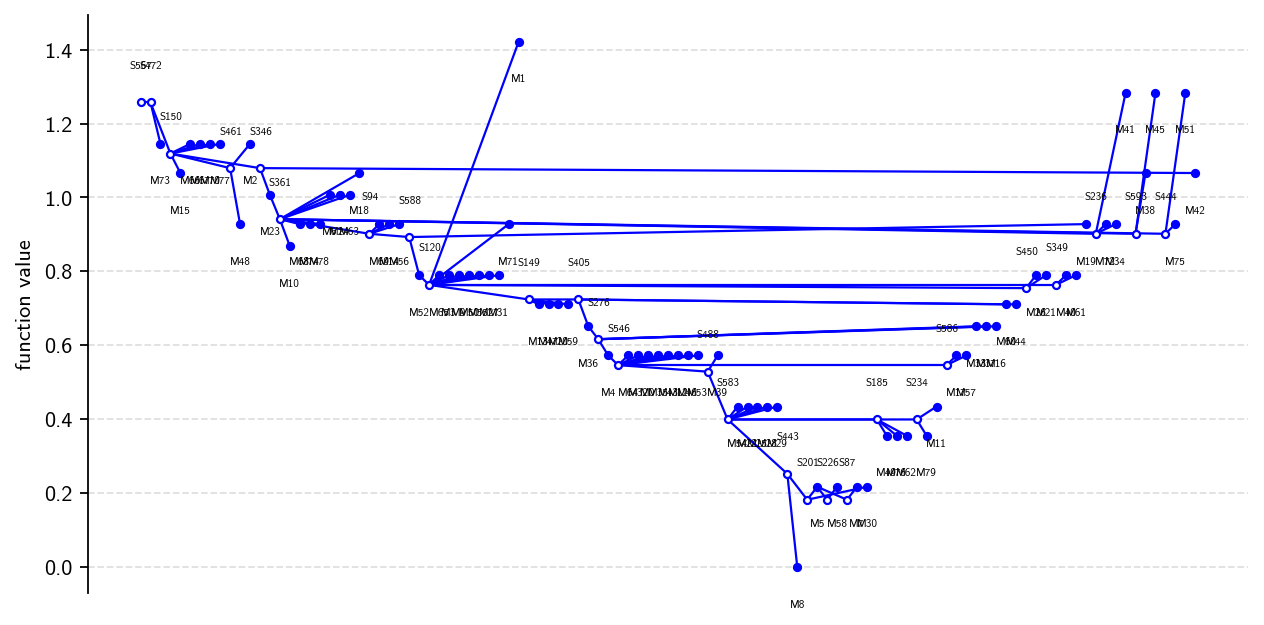

In [6]:
fig1 = plt.figure(figsize=(8,4), dpi=160)

fig1 = plot_saddle_tree_with_function(dataframe, 
                                      nodes_csv="results/tree_nodes.csv",
                                      edges_csv="results/tree_connectivity.csv", 
                                      fig=fig1,
                                      markersize=10,
                                      fontsize=5)

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.show()
fig1.savefig(outdir+"/tree_plot.png")  # Optional